In [1]:
import matplotlib.pyplot as plt
import numpy as np

from previous_HXs import hxs, mass_flows, pressure_changes

# -----------------------------
# Collect data
# -----------------------------

tube_lengths = []
num_tubes = []
num_baffles = []

abs_hot_errors = []
abs_cold_errors = []

hot_errors = []
cold_errors = []

for i, hx in enumerate(hxs):
    # Predictions
    dp_cold_pred = hx.cold_side_pressure_drop(mass_flows[i][0])
    dp_hot_pred  = hx.hot_side_pressure_drop(mass_flows[i][1])

    # Experimental values
    dp_cold_measured, dp_hot_measured = pressure_changes[i]
    # print(pressure_changes)

    # Relative errors (%)
    abs_error_cold = dp_cold_pred - dp_cold_measured
    abs_error_hot = dp_hot_pred - dp_hot_measured
    rel_error_cold = 100 * abs_error_cold / dp_cold_measured
    rel_error_hot  = 100 * abs_error_hot / dp_hot_measured

    # Store parameters
    tube_lengths.append(hx.tube_length)
    num_tubes.append(hx.number_of_tubes)
    num_baffles.append(hx.number_of_baffles)

    # Store errors
    abs_hot_errors.append(abs_error_hot)
    abs_cold_errors.append(abs_error_cold)
    
    hot_errors.append(rel_error_hot)
    cold_errors.append(rel_error_cold)

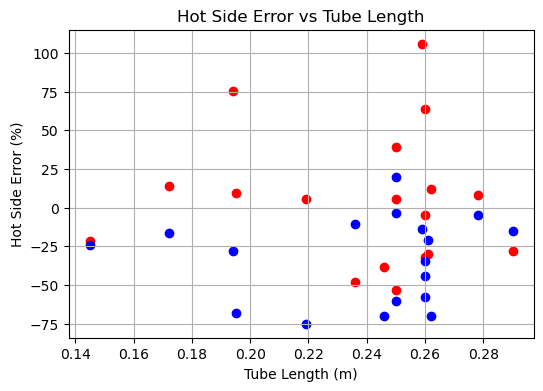

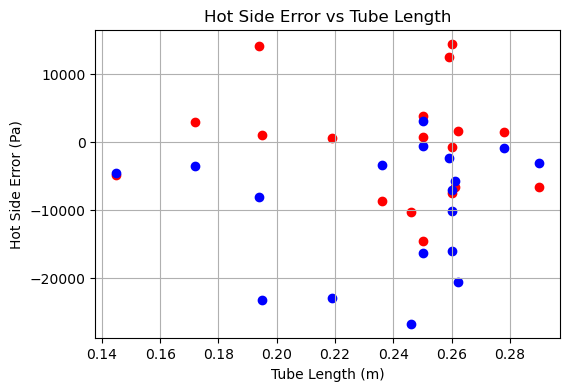

In [2]:
# -----------------------------
# Plot 1: Hot error vs tube length
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(tube_lengths, hot_errors,color='red')
plt.scatter(tube_lengths, cold_errors,color='blue')

# Optional linear fit
m, c = np.polyfit(tube_lengths, hot_errors, 1)
xfit = np.linspace(min(tube_lengths), max(tube_lengths), 100)
# plt.plot(xfit, m*xfit + c)

plt.xlabel("Tube Length (m)")
plt.ylabel("Hot Side Error (%)")
plt.title("Hot Side Error vs Tube Length")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(tube_lengths, abs_hot_errors,color='red')
plt.scatter(tube_lengths, abs_cold_errors,color='blue')

# Optional linear fit
m, c = np.polyfit(tube_lengths, abs_hot_errors, 1)
xfit = np.linspace(min(tube_lengths), max(tube_lengths), 100)
# plt.plot(xfit, m*xfit + c)

plt.xlabel("Tube Length (m)")
plt.ylabel("Hot Side Error (Pa)")
plt.title("Hot Side Error vs Tube Length")
plt.grid(True)

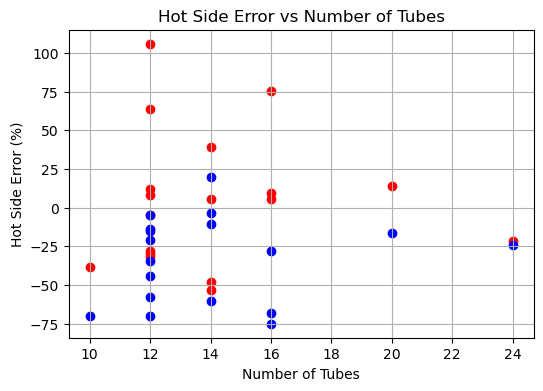

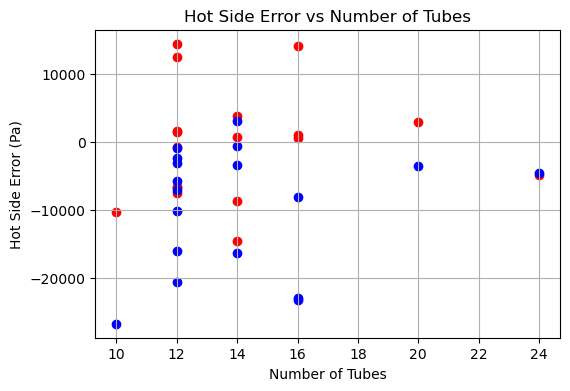

In [3]:
# -----------------------------
# Plot 2: Hot error vs number of tubes
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(num_tubes, hot_errors,color='red')
plt.scatter(num_tubes, cold_errors,color='blue')

m, c = np.polyfit(num_tubes, hot_errors, 1)
xfit = np.linspace(min(num_tubes), max(num_tubes), 100)
# plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Tubes")
plt.ylabel("Hot Side Error (%)")
plt.title("Hot Side Error vs Number of Tubes")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(num_tubes, abs_hot_errors,color='red')
plt.scatter(num_tubes, abs_cold_errors,color='blue')

m, c = np.polyfit(num_tubes, abs_hot_errors, 1)
xfit = np.linspace(min(num_tubes), max(num_tubes), 100)
# plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Tubes")
plt.ylabel("Hot Side Error (Pa)")
plt.title("Hot Side Error vs Number of Tubes")
plt.grid(True)
plt.show()

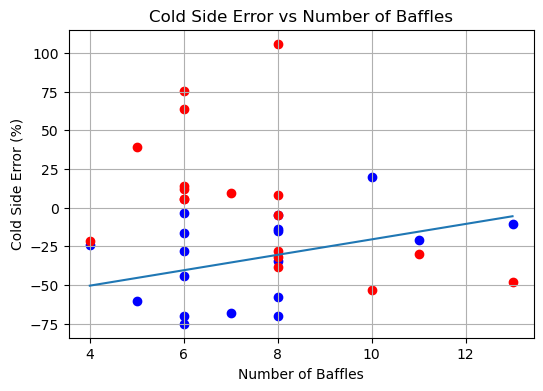

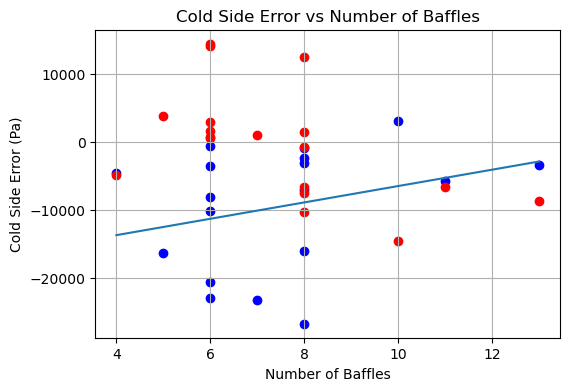

In [4]:
# -----------------------------
# Plot 3: Cold error vs number of baffles
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(num_baffles, cold_errors,color='blue')
plt.scatter(num_baffles, hot_errors,color='red')

m, c = np.polyfit(num_baffles, cold_errors, 1)
xfit = np.linspace(min(num_baffles), max(num_baffles), 100)
plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Baffles")
plt.ylabel("Cold Side Error (%)")
plt.title("Cold Side Error vs Number of Baffles")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(num_baffles, abs_cold_errors,color='blue')
plt.scatter(num_baffles, abs_hot_errors,color='red')

m, c = np.polyfit(num_baffles, abs_cold_errors, 1)
xfit = np.linspace(min(num_baffles), max(num_baffles), 100)
plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Baffles")
plt.ylabel("Cold Side Error (Pa)")
plt.title("Cold Side Error vs Number of Baffles")
plt.grid(True)
plt.show()

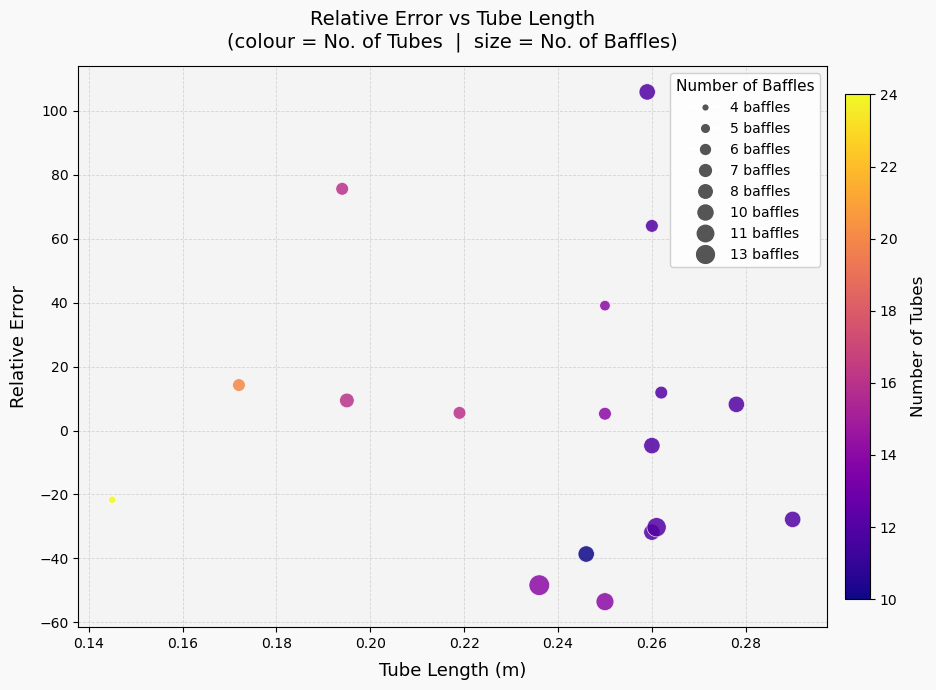

Plot saved to scatter_4d.png


In [5]:
"""
4D Scatter Plot: Relative Error vs Tube Length
  - X-axis : Tube Length
  - Y-axis : Relative Error
  - Colour : Number of Tubes   (continuous colormap + colorbar)
  - Size   : Number of Baffles (discrete sizes + legend)

Replace the sample data section with your real data.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

# ── 1. DATA ─────────────────────────────────────────────────────────────────
# Replace this block with your real arrays.
rng = np.random.default_rng(42)
n_points = 200

tube_length   = np.asarray(tube_lengths)          # metres
num_tubes     = np.asarray(num_tubes)           # integer count
num_baffles   = np.asarray(num_baffles)    # discrete values
relative_error = np.asarray(hot_errors)

# ── 2. COLOUR MAP (Number of Tubes) ─────────────────────────────────────────
cmap  = plt.get_cmap("plasma")
norm  = mcolors.Normalize(vmin=num_tubes.min(), vmax=num_tubes.max())
colors = cmap(norm(num_tubes))

# ── 3. MARKER SIZE (Number of Baffles) ──────────────────────────────────────
unique_baffles = sorted(np.unique(num_baffles))

# Map baffle counts → marker areas (pts²)
size_min, size_max = 30, 220
if len(unique_baffles) > 1:
    size_map = {
        b: size_min + (size_max - size_min) * i / (len(unique_baffles) - 1)
        for i, b in enumerate(unique_baffles)
    }
else:
    size_map = {unique_baffles[0]: (size_min + size_max) / 2}

sizes = np.array([size_map[b] for b in num_baffles])

# ── 4. PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#f9f9f9")
ax.set_facecolor("#f4f4f4")

sc = ax.scatter(
    tube_length,
    relative_error,
    c=colors,
    s=sizes,
    edgecolors="white",
    linewidths=0.5,
    alpha=0.85,
    zorder=3,
)

# ── 5. COLORBAR (Number of Tubes) ────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.9)
cbar.set_label("Number of Tubes", fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

# ── 6. SIZE LEGEND (Number of Baffles) ───────────────────────────────────────
legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#555",
        markeredgecolor="white",
        markersize=np.sqrt(size_map[b]),   # visual radius ∝ sqrt(area)
        label=f"{b} baffles",
    )
    for b in unique_baffles
]
legend = ax.legend(
    handles=legend_handles,
    title="Number of Baffles",
    title_fontsize=11,
    fontsize=10,
    loc="upper right",
    framealpha=0.9,
    edgecolor="#ccc",
)

# ── 7. LABELS & GRID ─────────────────────────────────────────────────────────
ax.set_xlabel("Tube Length (m)", fontsize=13, labelpad=8)
ax.set_ylabel("Relative Error", fontsize=13, labelpad=8)
ax.set_title(
    "Relative Error vs Tube Length\n"
    "(colour = No. of Tubes  |  size = No. of Baffles)",
    fontsize=14,
    pad=14,
)
ax.grid(True, linestyle="--", linewidth=0.6, color="#cccccc", alpha=0.8, zorder=1)
ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig("scatter_4d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to scatter_4d.png")